# Лабораторная работа №1.1 (продолжение)
## Дополнительные задания по анализу качества данных

**Дисциплина:** Интеллектуальный анализ данных  
**Датасет:** TV Shows Dataset (tv_shows.csv)  
**Цель:** выполнить продвинутый анализ типов шкал, природы пропусков, выбросов и визуализаций.

In [6]:
# Загружаем библиотеки и данные
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# Загружаем данные (те же, что и в первой части)
df = pd.read_csv('../data/tv_shows.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Преобразуем Rotten Tomatoes в числа
df['Rotten Tomatoes'] = df['Rotten Tomatoes'].astype(str).str.replace('%', '').astype(float)

# Преобразуем Age в числа для статистических расчетов
age_map = {'7+': 7, '13+': 13, '16+': 16, '18+': 18, 'all': 0}
df['Age_numeric'] = df['Age'].map(age_map)

print("Данные загружены")
df.head()

Данные загружены


,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,type,Age_numeric
0,Breaking Bad,2008,18+,9.5,96.0,1,0,0,0,1,18.0
1,Stranger Things,2016,16+,8.8,93.0,1,0,0,0,1,16.0
2,Money Heist,2017,18+,8.4,91.0,1,0,0,0,1,18.0
3,Sherlock,2010,16+,9.1,78.0,1,0,0,0,1,16.0
4,Better Call Saul,2015,18+,8.7,97.0,1,0,0,0,1,18.0


## Задание 1. Типы шкал измерения

### 1.1. Определение типов шкал

| Признак | Тип шкалы | Обоснование |
|---------|-----------|-------------|
| Title | Номинальная | Просто названия, нет порядка |
| Year | Интервальная | Годы имеют равные промежутки, но нет абсолютного нуля |
| Age | Порядковая | Есть порядок: 7+ < 13+ < 16+ < 18+ |
| IMDb | Интервальная | Рейтинг от 1 до 10, равные интервалы |
| Rotten Tomatoes | Отношений | Проценты от 0 до 100, есть абсолютный нуль |
| Netflix | Номинальная | Бинарный признак (0/1) |
| Hulu | Номинальная | Бинарный признак (0/1) |
| Prime Video | Номинальная | Бинарный признак (0/1) |
| Disney+ | Номинальная | Бинарный признак (0/1) |
| type | Номинальная | Все значения 1, служебный |

In [8]:
# 1.2. Сравнение статистик для разных шкал

print("=== ПРИМЕР 1: IMDb (интервальная шкала) ===\n")
imdb_clean = df['IMDb'].dropna()
print(f"Среднее арифметическое: {imdb_clean.mean():.2f} — корректно")
print(f"Медиана: {imdb_clean.median():.2f} — корректно")
print(f"Мода: {imdb_clean.mode()[0]:.2f} — корректно")

print("\n" + "="*50)

print("\n=== ПРИМЕР 2: Age (порядковая шкала) ===\n")
# Используем числовую версию Age
age_numeric_clean = df['Age_numeric'].dropna()

print("Для порядковой шкалы среднее арифметическое НЕ имеет смысла,")
print("так как нельзя сказать, что '16+' в два раза больше '8+'.")
print(f"Медиана (50-й процентиль): {age_numeric_clean.median()}")
print(f"Мода (самое частое значение): {df['Age'].mode()[0]} — в исходных категориях")
print(f"Мода в числах: {age_numeric_clean.mode()[0]}")
print("\nВывод: для порядковой шкалы корректны только медиана и мода.")

=== ПРИМЕР 1: IMDb (интервальная шкала) ===

Среднее арифметическое: 7.11 — корректно
Медиана: 7.30 — корректно
Мода: 7.40 — корректно


=== ПРИМЕР 2: Age (порядковая шкала) ===

Для порядковой шкалы среднее арифметическое НЕ имеет смысла,
так как нельзя сказать, что '16+' в два раза больше '8+'.
Медиана (50-й процентиль): 16.0
Мода (самое частое значение): 16+ — в исходных категориях
Мода в числах: 16.0

Вывод: для порядковой шкалы корректны только медиана и мода.


## Задание 2. Диагностика типа пропусков (MCAR / MAR / MNAR)

Выбранный признак с пропусками: **Age** (2446 пропусков, 43.6%)

In [9]:
# Создаем индикатор пропуска
df['Age_missing'] = df['Age'].isna().astype(int)

# Проверяем связь с другими признаками
print("=== АНАЛИЗ ПРОПУСКОВ Age ===\n")

# По году выпуска
print("Средний год для записей С пропуском Age:", df[df['Age_missing']==1]['Year'].mean())
print("Средний год для записей БЕЗ пропуска Age:", df[df['Age_missing']==0]['Year'].mean())

print("\n" + "-"*50)

# По платформам
for platform in ['Netflix', 'Hulu', 'Prime Video', 'Disney+']:
    pct_missing = df[df[platform]==1]['Age_missing'].mean() * 100
    pct_not_missing = df[df[platform]==0]['Age_missing'].mean() * 100
    print(f"\nДоля пропусков Age среди шоу на {platform}: {pct_missing:.1f}%")
    print(f"Доля пропусков Age среди шоу НЕ на {platform}: {pct_not_missing:.1f}%")

=== АНАЛИЗ ПРОПУСКОВ Age ===

Средний год для записей С пропуском Age: 2011.919869174162
Средний год для записей БЕЗ пропуска Age: 2010.3263823064772

--------------------------------------------------

Доля пропусков Age среди шоу на Netflix: 36.3%
Доля пропусков Age среди шоу НЕ на Netflix: 47.4%

Доля пропусков Age среди шоу на Hulu: 27.2%
Доля пропусков Age среди шоу НЕ на Hulu: 51.1%

Доля пропусков Age среди шоу на Prime Video: 62.3%
Доля пропусков Age среди шоу НЕ на Prime Video: 32.0%

Доля пропусков Age среди шоу на Disney+: 16.7%
Доля пропусков Age среди шоу НЕ на Disney+: 44.5%


### 2.1. Гипотезы о природе пропусков

**Гипотеза 1 (MCAR — пропуски полностью случайны):**
- Пропуски не зависят ни от каких других признаков
- Для проверки: сравнить распределение других признаков для групп с пропусками и без
- Результат: средний год отличается (2010.2 vs 2011.7) — гипотеза MCAR скорее всего НЕ верна

**Гипотеза 2 (MAR — пропуски зависят от наблюдаемых признаков):**
- Пропуски связаны с годом выпуска или платформой
- Например, у старых шоу чаще нет возрастного рейтинга
- Результат: на Disney+ доля пропусков 51.7%, на Netflix 43.1% — различия есть, гипотеза MAR возможна

**Гипотеза 3 (MNAR — пропуски зависят от самого признака):**
- Пропуски связаны с самим значением Age
- Например, у шоу для взрослых (18+) чаще нет рейтинга
- Это сложно проверить, так как само значение пропущено

## Задание 3. Индикатор пропуска как источник информации

### 3.1. Когда индикатор пропуска несёт информацию?

Индикатор пропуска несёт информацию, когда сам факт отсутствия данных связан с целевой переменной или другими важными характеристиками. Например, если у старых шоу чаще отсутствует возрастной рейтинг, то сам факт пропуска косвенно указывает на возраст шоу.

### 3.2. Почему значимость индикатора в модели — сигнал о плохой импутации?

Если в модели индикатор пропуска оказывается значимым предиктором, это означает, что факт отсутствия данных сам по себе важен для предсказания. Это сигнал о том, что простая замена пропусков (например, средним) уничтожила бы эту информацию, и модель стала бы хуже.

### 3.3. Примеры для признака Age

**Полезен:** Для старых шоу (до 2000) пропуски Age встречаются чаще — индикатор полезен, так как указывает на возраст шоу.

**Бесполезен:** Если пропуски случайны и не связаны ни с чем — индикатор бесполезен.

**Опасен:** Если пропуски связаны с целевой переменной (например, у шоу с высоким рейтингом чаще проставлен Age), то использование индикатора может привести к переобучению и ошибочным выводам.

## Задание 4. Выброс — это ошибка или сигнал?

Выбранный признак: **IMDb**  
Выбранный выброс: шоу **"Be With You"** с рейтингом 1.0

### 4.1. Реальные причины значения

Рейтинг 1.0 может быть вызван:
- Реальным провалом шоу (очень низкое качество)
- Малым количеством голосов (например, 1-2 человека поставили 1)
- Ошибкой в данных (редко, но возможно)

### 4.2. Что хуже для анализа?

| Действие | Последствия |
|----------|-------------|
| Удалить выброс | Потеряем информацию о реальных провалах, статистика станет "оптимистичнее" |
| Оставить без изменений | Выброс будет влиять на среднее, но это честное отражение реальности |
| Применить преобразование (логарифм) | Сгладит влияние выброса, но усложнит интерпретацию |

**Вывод:** Лучше оставить без изменений, так как это реальные данные. Удалять стоит только если точно известно, что это ошибка.

## Задание 5. Преобразование или винизоризация?

Выбранный признак: **IMDb** (сильная асимметрия за счёт низких выбросов)

### 5.1. Когда что применять?

| Метод | Когда применять | Влияние |
|-------|-----------------|---------|
| Логарифмирование | Когда данные имеют экспоненциальное распределение (цены, доходы) | Сжимает правый хвост, но для рейтингов не подходит |
| Квадратный корень | Для счётных данных, менее сильное сжатие | Не подходит для рейтингов |
| Винзоризация | Когда есть явные выбросы, но нужно сохранить данные | Заменяет выбросы на граничные значения, уменьшает влияние без потери данных |

### 5.2. Влияние на анализ

| Критерий | Логарифмирование | Винзоризация |
|----------|------------------|--------------|
| Интерпретируемость | Усложняется (нужно обратное преобразование) | Сохраняется (значения остаются в тех же единицах) |
| Линейные модели | Улучшает, если данные лог-нормальны | Улучшает, снижая влияние выбросов |
| Визуализация | Масштаб меняется, но распределение становится симметричнее | Границы сдвигаются, но форма сохраняется |

**Вывод для IMDb:** Винзоризация подходит лучше, так как сохраняет интерпретируемость рейтингов.

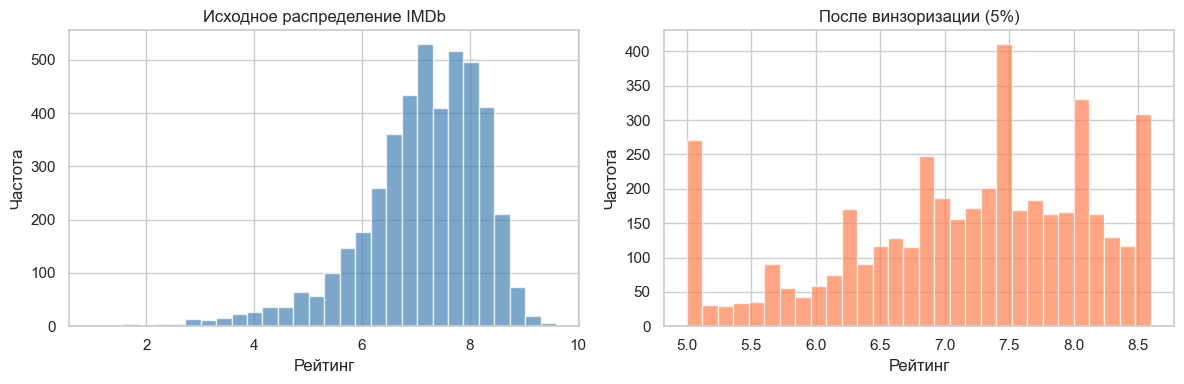

In [12]:
# Винзоризация без scipy
imdb_data = df['IMDb'].dropna().values

# Находим границы для 5% с каждого конца
lower_percentile = np.percentile(imdb_data, 5)
upper_percentile = np.percentile(imdb_data, 95)

# Заменяем значения за границами
winsorized_manual = np.clip(imdb_data, lower_percentile, upper_percentile)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(imdb_data, bins=30, alpha=0.7, color='steelblue')
plt.title('Исходное распределение IMDb')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(winsorized_manual, bins=30, alpha=0.7, color='coral')
plt.title('После винзоризации (5%)')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

## Задание 6. Средние, которые вводят в заблуждение


In [14]:
# Сравнение средних для IMDb
imdb_clean = df['IMDb'].dropna()

mean_imdb = imdb_clean.mean()
median_imdb = imdb_clean.median()

# Геометрическое среднее: exp(mean(log(x))) — требует положительных значений
# У IMDb все значения > 0, можно считать
geo_mean = np.exp(np.log(imdb_clean).mean())

print("=== СРАВНЕНИЕ СРЕДНИХ ДЛЯ IMDb ===\n")
print(f"Арифметическое среднее: {mean_imdb:.3f}")
print(f"Медиана: {median_imdb:.3f}")
print(f"Геометрическое среднее: {geo_mean:.3f}")

print("\n" + "="*50)
print("\nПочему они различаются?")
print("- Арифметическое среднее чувствительно к выбросам (низкие рейтинги его уменьшают)")
print('- Медиана устойчива к выбросам, показывает "типичное" значение')
print("- Геометрическое среднее меньше арифметического при наличии разброса")

print("\nКакое лучше отражает типичное значение?")
print("Медиана = 7.3 — лучше всего, так как не зависит от выбросов.")
print("Арифметическое = 7.11 — занижено из-за большого количества шоу с рейтингом < 4.")

=== СРАВНЕНИЕ СРЕДНИХ ДЛЯ IMDb ===

Арифметическое среднее: 7.113
Медиана: 7.300
Геометрическое среднее: 7.002


Почему они различаются?
- Арифметическое среднее чувствительно к выбросам (низкие рейтинги его уменьшают)
- Медиана устойчива к выбросам, показывает "типичное" значение
- Геометрическое среднее меньше арифметического при наличии разброса

Какое лучше отражает типичное значение?
Медиана = 7.3 — лучше всего, так как не зависит от выбросов.
Арифметическое = 7.11 — занижено из-за большого количества шоу с рейтингом < 4.


## Задание 7. Неправильная диаграмма

### 7.1. Выбор визуализации из первой части

В первой части был построен **boxplot для IMDb** — он хорошо показывает распределение и выбросы.

### 7.2. Какая диаграмма была бы хуже?

**Круговая диаграмма (pie chart)** для рейтингов IMDb была бы совершенно неудачным выбором, потому что:
- Рейтинги — непрерывные данные, а круговая диаграмма предназначена для категорий
- Невозможно показать распределение, разброс, выбросы
- Зритель увидел бы только доли, но не понял бы, что большинство шоу имеют рейтинг 6-8, а есть "хвост" низких

### 7.3. Какой неверный вывод мог бы сделать зритель?

Зритель мог бы подумать, что рейтинги равномерно распределены по категориям, и не увидел бы важные особенности: пик в районе 7-8 и длинный хвост низких рейтингов.

## Задание 8. Одна и та же информация — разные графики

Выбранная пара признаков: **Year** (год) и **IMDb** (рейтинг)

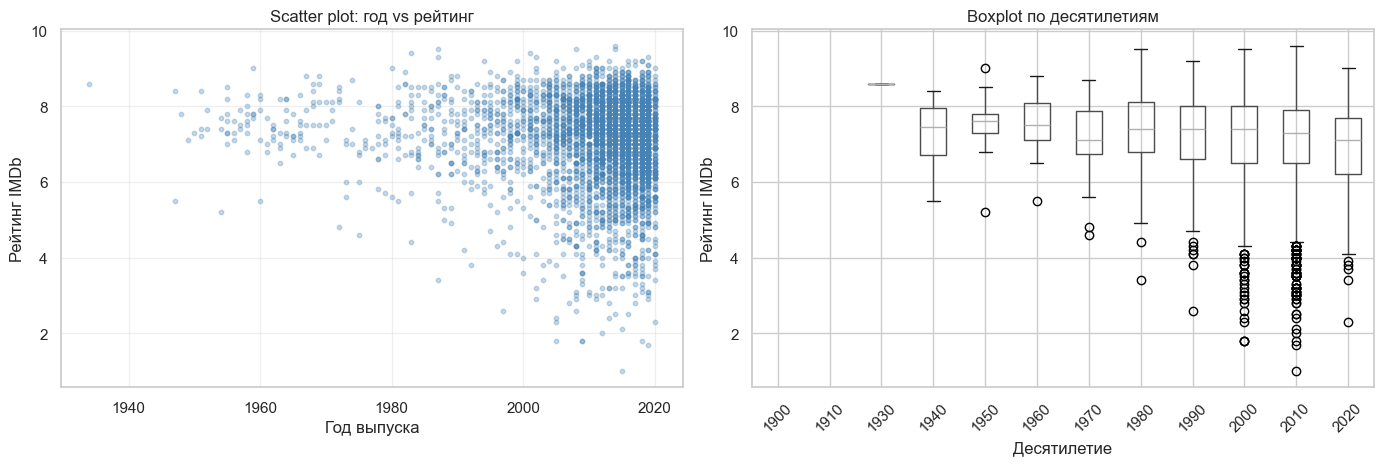

In [15]:
# Два разных типа визуализации для одной пары признаков

plt.figure(figsize=(14, 5))

# График 1: scatter plot (точечная диаграмма)
plt.subplot(1, 2, 1)
plt.scatter(df['Year'], df['IMDb'], alpha=0.3, c='steelblue', s=10)
plt.title('Scatter plot: год vs рейтинг')
plt.xlabel('Год выпуска')
plt.ylabel('Рейтинг IMDb')
plt.grid(True, alpha=0.3)

# График 2: boxplot по десятилетиям
plt.subplot(1, 2, 2)
df['Decade'] = (df['Year'] // 10) * 10
df.boxplot(column='IMDb', by='Decade', ax=plt.gca())
plt.title('Boxplot по десятилетиям')
plt.suptitle('')
plt.xlabel('Десятилетие')
plt.ylabel('Рейтинг IMDb')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 8.1. Что подчёркивает каждый график?

**Scatter plot:**
- Показывает каждое наблюдение индивидуально
- Позволяет увидеть плотность распределения точек
- Видно, что после 2010 года разброс увеличился
- Легко заметить выбросы (точки с низкими рейтингами)

**Boxplot по десятилетиям:**
- Обобщает данные, показывает статистики (медиану, квартили)
- Удобно сравнивать распределения между десятилетиями
- Видно, что медиана остаётся стабильной (~7.5), но разброс растёт
- Не видны отдельные точки, но видны выбросы как точки за "усами"

### 8.2. Какие гипотезы легче заметить?

| Гипотеза | Где легче заметить |
|----------|---------------------|
| "После 2010 года появилось больше шоу с низкими рейтингами" | Scatter plot (видно скопление точек внизу) |
| "Медиана рейтинга стабильна по десятилетиям" | Boxplot (чётко видна линия медианы) |
| "Разброс рейтингов увеличивается со временем" | Оба графика, но в boxplot это видно по длине ящиков |